In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv('../csv/Titanic_cleaned.csv')

In [29]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,2,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Sex_female   891 non-null    int64  
 8   Sex_male     891 non-null    int64  
 9   Embarked_C   891 non-null    int64  
 10  Embarked_Q   891 non-null    int64  
 11  Embarked_S   891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB


In [31]:
x = df.drop('Survived', axis=1)
y = df['Survived']
x.shape, y.shape

((891, 11), (891,))

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 11), (179, 11), (712,), (179,))

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

In [35]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

LogisticRegression()

In [36]:
train_pred = log_reg.predict(x_train)
f1_train = f1_score(y_train, train_pred)
print(f"F1 Score on Training Data: {f1_train:.4f}")

F1 Score on Training Data: 0.7331


In [37]:
test_pred = log_reg.predict(x_test)
f1_test = f1_score(y_test, test_pred)
print(f"F1 Score on Test Data: {f1_test:.4f}")

F1 Score on Test Data: 0.7132


In [38]:
# the result is not bad, but let's try to improve it!

In [39]:
# let's checkout the coefficients of the model to see which features are more important

In [40]:
log_reg.coef_

array([[ 0.16174136, -2.02785205, -2.0350286 , -0.98408501, -0.37826758,
         0.4339568 ,  1.27535878, -1.28645575,  0.08650787,  0.27367626,
        -0.3712811 ]])

Text(0.5, 1.0, 'Feature Importance in Logistic Regression Model')

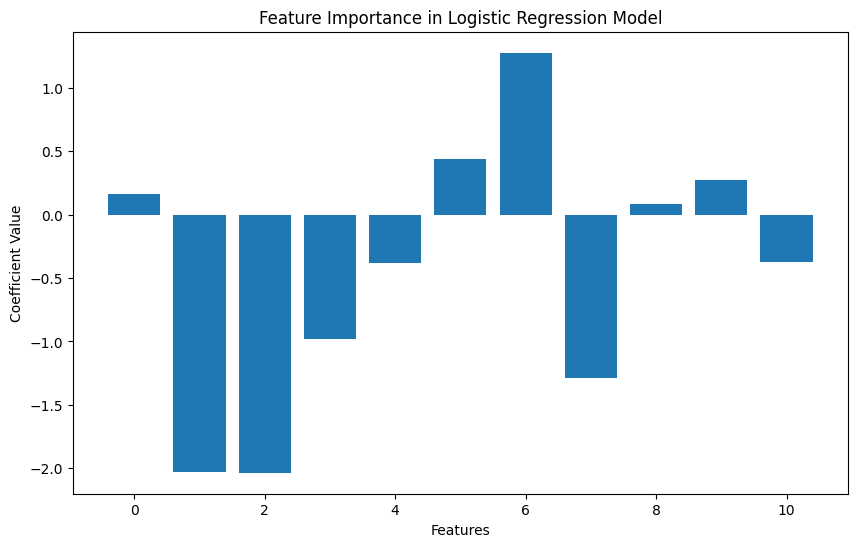

In [41]:
plt.figure(figsize=(10, 6), dpi=100, facecolor='w', edgecolor='k')
x_coef = range(len(x.columns))
c = log_reg.coef_[0]
plt.bar(x_coef, c)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression Model')

In [47]:
# Let's apply the capsize at minimum of 0.5 to filter out less important features

In [48]:
coef_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': log_reg.coef_[0]})
coef_df.head()

,Feature,Coefficient
0,PassengerId,0.161741
1,Pclass,-2.027852
2,Age,-2.035029
3,SibSp,-0.984085
4,Parch,-0.378268


In [49]:
req_coef = coef_df[coef_df['Coefficient'].abs() > 0.5]

In [50]:
subset_req = x[req_coef['Feature'].values]

In [53]:
subset_req.head()

,Pclass,Age,SibSp,Sex_female,Sex_male
0,3,22.0,1,0,1
1,1,38.0,1,1,0
2,3,26.0,0,1,0
3,1,35.0,1,1,0
4,3,35.0,0,0,1


In [54]:
x_scaled_req = scaler.fit_transform(subset_req)

In [55]:
train_x_req, test_x_req, train_y_req, test_y_req = train_test_split(x_scaled_req, y, test_size=0.2, random_state=42, stratify=y)
train_x_req.shape, test_x_req.shape, train_y_req.shape, test_y_req.shape

((712, 5), (179, 5), (712,), (179,))

In [56]:
log_reg.fit(train_x_req, train_y_req)
log_reg.coef_

array([[-2.081257  , -2.00811443, -1.16239585,  1.29374426, -1.28857298]])

In [57]:
train_pred_req = log_reg.predict(train_x_req)
f1_train_req = f1_score(train_y_req, train_pred_req)
print(f"F1 Score on Training Data (Reduced Features): {f1_train_req:.4f}")

F1 Score on Training Data (Reduced Features): 0.7266


In [59]:
test_pred_req = log_reg.predict(test_x_req)
f1_test_req = f1_score(test_y_req, test_pred_req)
print(f"F1 Score on Test Data (Reduced Features): {f1_test_req:.4f}")

F1 Score on Test Data (Reduced Features): 0.7244


In [60]:
# Cool, so now, we have only the features that are impacting most the model and also imporved our test f1_score.